/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Dataset Filtering Analysis
This notebook analyzes how filtering affects the MathInstruct dataset size and source composition.
We'll visualize the dataset before and after filtering specific sources.

### Loading Dataset
Dataset loaded: 262039 examples

### Source Distribution Before Filtering
Number of unique sources: 14
Top 10 sources by example count:
                            source  count
0           data/CoT/aqua_rat.json  89343
1      data/CoT/math50k_camel.json  49484
2            data/CoT/gsm_rft.json  28215
3             data/PoT/mathqa.json  24382
4           data/PoT/gsm_gpt4.json  14591
5            data/PoT/numglue.json  13474
6         data/CoT/MATH_train.json  11239
7         data/PoT/MATH_train.json  10632
8  data/PoT/aqua_rat_filtered.json   9772
9          data/CoT/gsm_train.json   7473


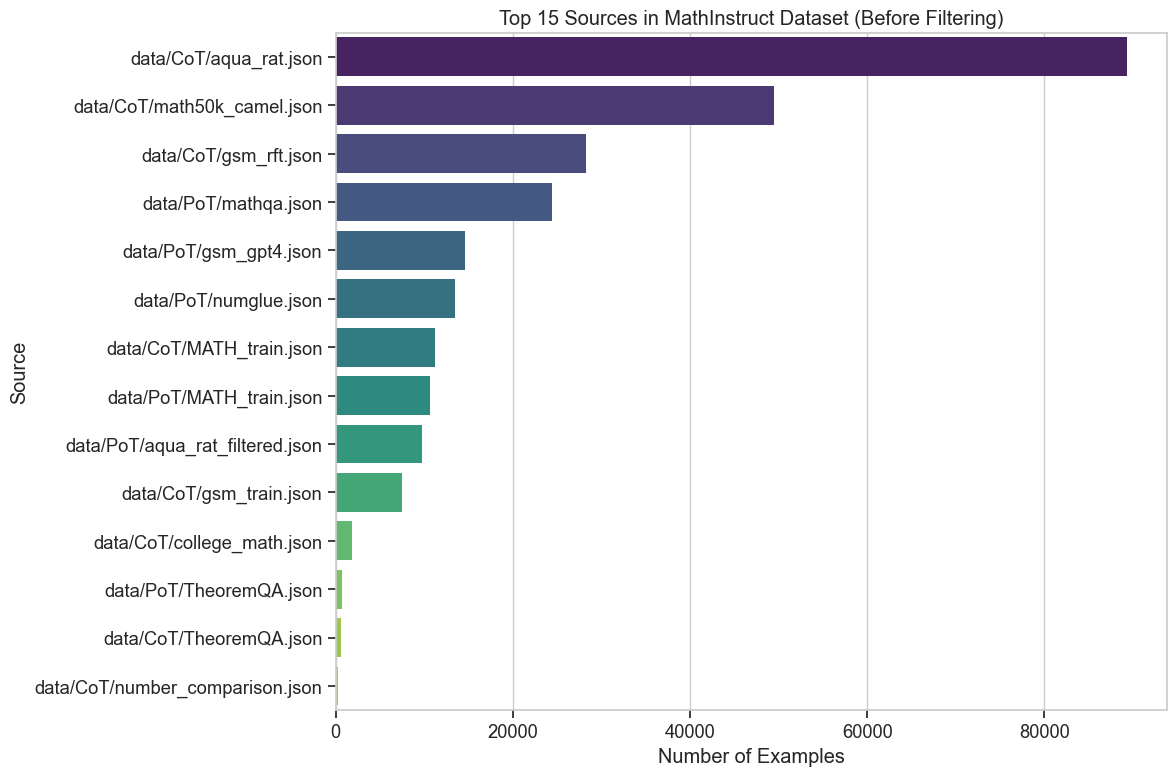


Number of examples with source starting with 'data/PoT/': 73553

Number of examples to be filtered out: 198584
Percentage of dataset filtered out: 75.78%

Filtered dataset size: 63455 examples
Retained 24.22% of the original dataset

### Source Distribution After Filtering
Number of unique sources: 5
Top 10 sources by example count:
                            source  count
0      data/CoT/math50k_camel.json  49484
1         data/CoT/MATH_train.json  11239
2       data/CoT/college_math.json   1840
3          data/CoT/TheoremQA.json    592
4  data/CoT/number_comparison.json    300


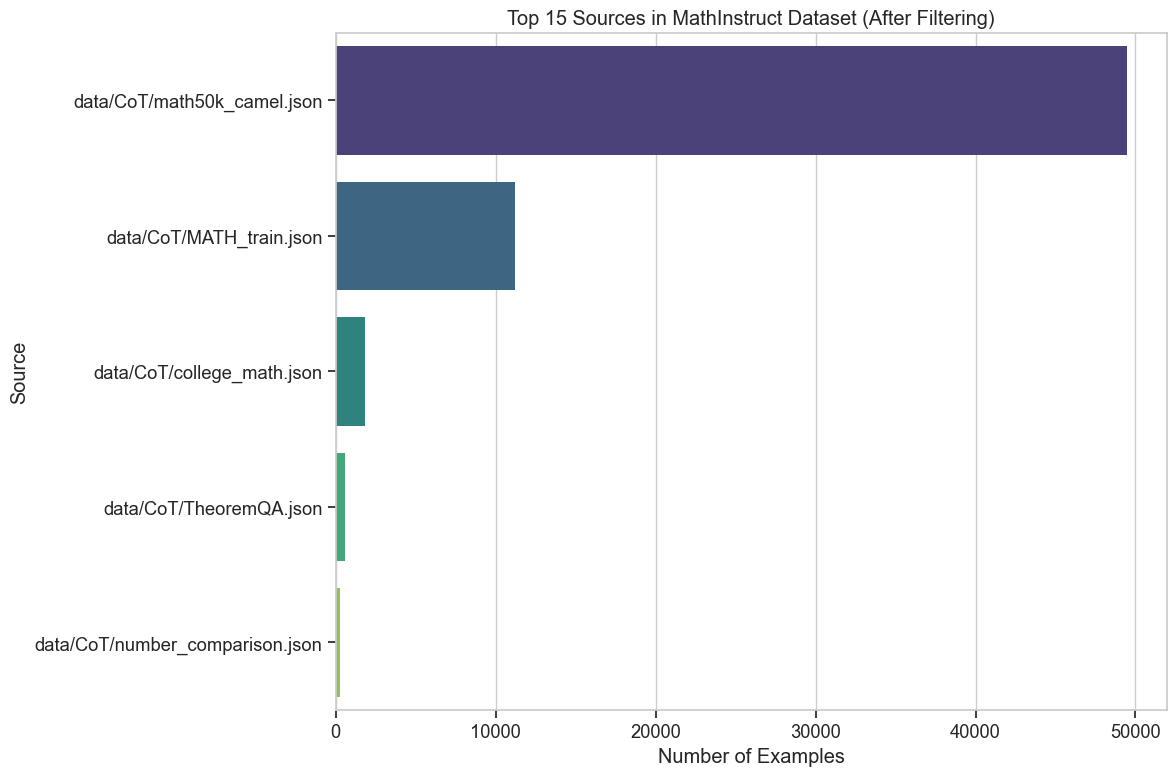

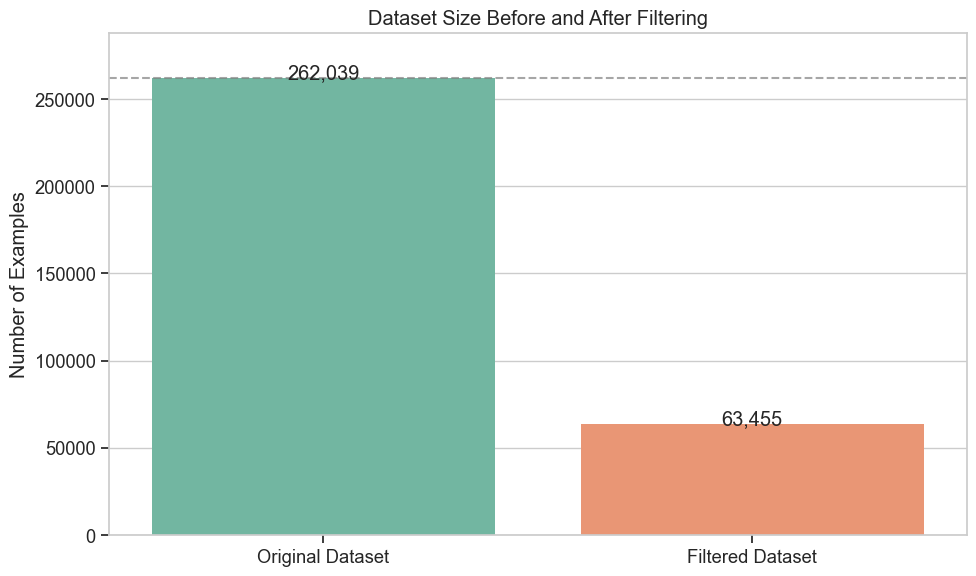


### Sources Completely Removed: 9
{'data/CoT/gsm_train.json', 'data/PoT/TheoremQA.json', 'data/PoT/MATH_train.json', 'data/PoT/mathqa.json', 'data/PoT/gsm_gpt4.json', 'data/CoT/gsm_rft.json', 'data/CoT/aqua_rat.json', 'data/PoT/numglue.json', 'data/PoT/aqua_rat_filtered.json'}


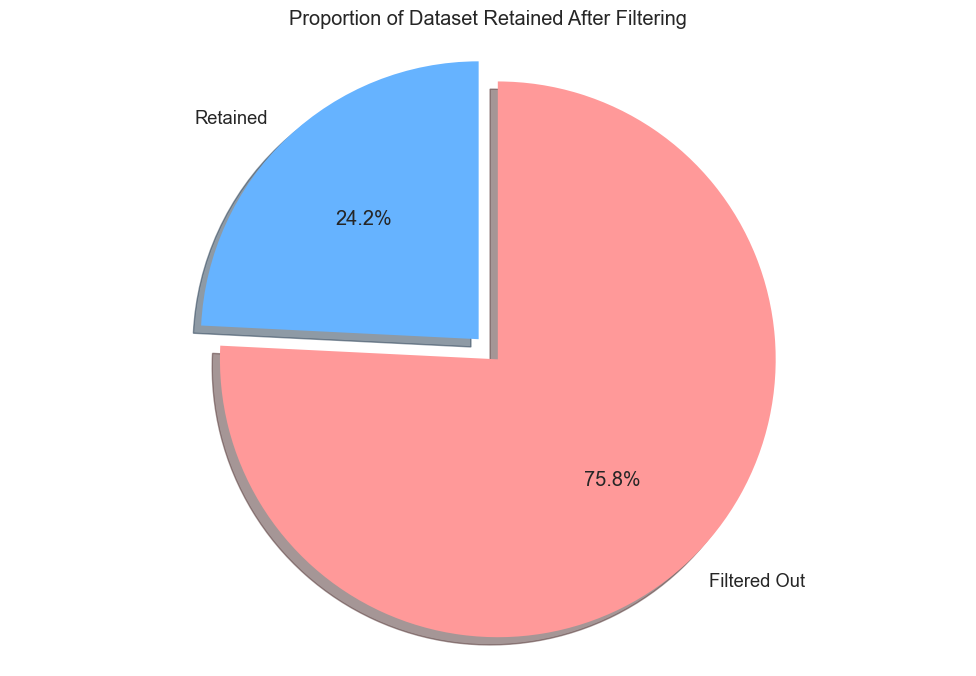

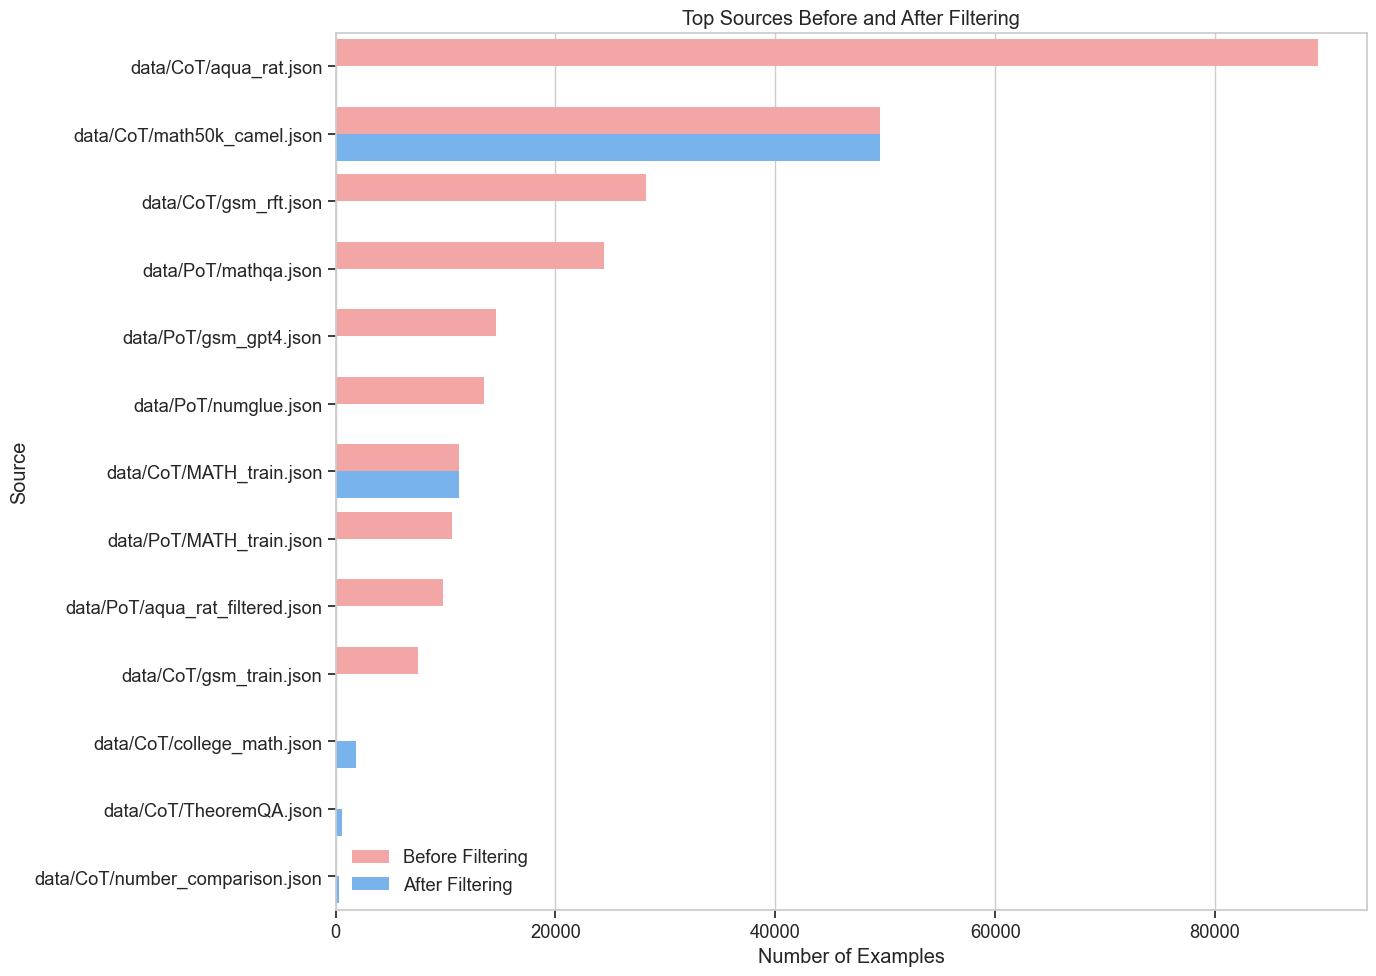

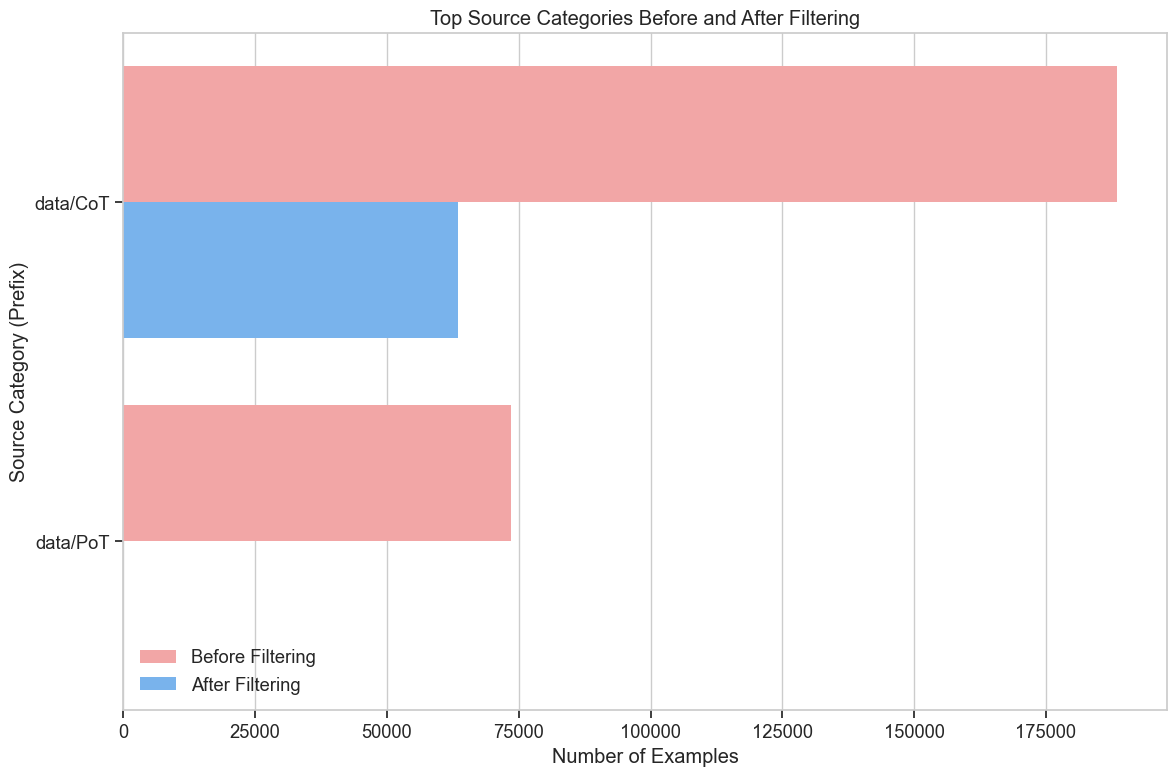


### Summary of Filtering Impact
                       Metric    Value
0       Original Dataset Size  262,039
1       Filtered Dataset Size   63,455
2  Number of Examples Removed  198,584
3         Percentage Retained   24.22%
4     Original Unique Sources       14
5     Filtered Unique Sources        5
6  Sources Completely Removed        9


In [1]:
# MathInstruct Dataset Analysis
# This notebook analyzes how filtering affects the dataset size and composition

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_dataset
from collections import Counter
import os

# Create output directory if it doesn't exist
output_dir = "/Users/jonathan/Library/Mobile Documents/com~apple~CloudDocs/Master/Master Thesis/math-reasoning-in-language-models/plots/plots_images/eda"
os.makedirs(output_dir, exist_ok=True)

# Set the style for prettier visualizations and increase font size
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_context("notebook", font_scale=1.5)  # Increased font scale

# Create a markdown cell describing the purpose of this analysis
print("## Dataset Filtering Analysis")
print("This notebook analyzes how filtering affects the MathInstruct dataset size and source composition.")
print("We'll visualize the dataset before and after filtering specific sources.")

# Load the TIGER-Lab/MathInstruct dataset
print("\n### Loading Dataset")
dataset = load_dataset("TIGER-Lab/MathInstruct", split="train")
print(f"Dataset loaded: {len(dataset)} examples")

# Create a dataframe for easier manipulation
df = pd.DataFrame({
    'source': dataset['source'],
    'instruction': dataset['instruction'],
    'output': dataset['output']
})

# Analyze sources before filtering
source_counts = Counter(dataset["source"])
source_df = pd.DataFrame({
    'source': list(source_counts.keys()),
    'count': list(source_counts.values())
}).sort_values('count', ascending=False).reset_index(drop=True)

print("\n### Source Distribution Before Filtering")
print(f"Number of unique sources: {len(source_df)}")
print(f"Top 10 sources by example count:")
print(source_df.head(10))

# Visualize top sources before filtering
plt.figure(figsize=(14, 10))
top_n = 15  # Show top 15 sources
top_sources = source_df.head(top_n)

ax = sns.barplot(x='count', y='source', data=top_sources)  # Using default color palette
plt.xlabel('Number of Examples', fontsize=16)
plt.ylabel('Source', fontsize=16)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'top_sources_before_filtering.png'), dpi=300)
plt.show()

# Define sources to be filtered out (same as in your script)
sources_to_filter = [
    "data/PoT/",  # Original filter (filter anything starting with "data/PoT/")
    "data/CoT/gsm_rft.json",
    "data/CoT/gsm_train.json",
    "data/CoT/aqua_rat.json",
]

# Analyze which examples will be filtered out
pot_examples = [example for example in dataset["source"] if example.startswith("data/PoT/")]
print(f"\nNumber of examples with source starting with 'data/PoT/': {len(pot_examples)}")

# Define filter function
def is_filtered(source):
    for s in sources_to_filter:
        if s.endswith("/"):
            if source.startswith(s):
                return True
        else:
            if source == s:
                return True
    return False

# Apply filter
df['filtered'] = df['source'].apply(is_filtered)

# Count total filtered examples
filtered_out = df[df['filtered'] == True]
print(f"\nNumber of examples to be filtered out: {len(filtered_out)}")
print(f"Percentage of dataset filtered out: {len(filtered_out) / len(df) * 100:.2f}%")

# Create filtered dataset
filtered_df = df[df['filtered'] == False]
print(f"\nFiltered dataset size: {len(filtered_df)} examples")
print(f"Retained {len(filtered_df) / len(df) * 100:.2f}% of the original dataset")

# Analyze sources in filtered dataset
filtered_source_counts = Counter(filtered_df["source"])
filtered_source_df = pd.DataFrame({
    'source': list(filtered_source_counts.keys()),
    'count': list(filtered_source_counts.values())
}).sort_values('count', ascending=False).reset_index(drop=True)

print("\n### Source Distribution After Filtering")
print(f"Number of unique sources: {len(filtered_source_df)}")
print(f"Top 10 sources by example count:")
print(filtered_source_df.head(10))

# Visualize top sources after filtering
plt.figure(figsize=(14, 10))
filtered_top_n = 15  # Show top 15 sources
filtered_top_sources = filtered_source_df.head(filtered_top_n)

ax = sns.barplot(x='count', y='source', data=filtered_top_sources)  # Using default color palette
plt.xlabel('Number of Examples', fontsize=16)
plt.ylabel('Source', fontsize=16)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'top_sources_after_filtering.png'), dpi=300)
plt.show()

# Compare dataset size before and after filtering with a bar chart
plt.figure(figsize=(12, 8))
sizes = [len(df), len(filtered_df)]
labels = ['Original Dataset', 'Filtered Dataset']
ax = sns.barplot(x=labels, y=sizes)  # Using default color palette
for i, size in enumerate(sizes):
    plt.text(i, size + 0.1, f"{size:,}", ha='center', fontsize=14)
plt.ylabel('Number of Examples', fontsize=16)
plt.ylim(0, max(sizes) * 1.1)  # Add some space for the text
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'dataset_size_comparison.png'), dpi=300)
plt.show()

# Analyze and visualize the filtering impact per source type
# Get sources that are completely removed vs partially filtered
completely_removed = set(source_df['source']) - set(filtered_source_df['source'])
print(f"\n### Sources Completely Removed: {len(completely_removed)}")
if len(completely_removed) <= 10:
    print(completely_removed)
else:
    print(f"Top 10 (out of {len(completely_removed)}):")
    print(list(completely_removed)[:10])

# Summary table of filtering impact
print("\n### Summary of Filtering Impact")
summary = pd.DataFrame({
    'Metric': [
        'Original Dataset Size',
        'Filtered Dataset Size',
        'Number of Examples Removed',
        'Percentage Retained',
        'Original Unique Sources',
        'Filtered Unique Sources',
        'Sources Completely Removed'
    ],
    'Value': [
        f"{len(df):,}",
        f"{len(filtered_df):,}",
        f"{len(df) - len(filtered_df):,}",
        f"{len(filtered_df) / len(df) * 100:.2f}%",
        f"{len(source_df):,}",
        f"{len(filtered_source_df):,}",
        f"{len(completely_removed):,}"
    ]
})
print(summary)